# **Maestría en Inteligencia Artificial Aplicada**

## **Curso: Inteligencia Artificial y Aprendizaje Automático**

#### **Tecnológico de Monterrey**

#### **Prof Luis Eduardo Falcón Morales**

#### Tema de la Actividad de las Semana:

#### **Problema de asignación de créditos - South German Dataset.**


**Nombres y matrículas:**

* None
* None
* None


* Liga del dataset: https://archive.ics.uci.edu/dataset/522/south+german+credit

* Liga del artículo de la IEEE: https://ieeexplore.ieee.org/stamp/stamp.jsp?tp=&arnumber=9239944


# **Ejercicio 1**

In [68]:
# Aquí deberás incluir todas las librerías que requieras durante esta actividad:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, OrdinalEncoder            
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [69]:
# Cargamos los datos:

df = pd.read_csv("SouthGermanCredit.asc",sep=' ')
print(df.shape)
df.head(3)

(1000, 21)


,laufkont,laufzeit,moral,verw,hoehe,sparkont,beszeit,rate,famges,buerge,...,verm,alter,weitkred,wohn,bishkred,beruf,pers,telef,gastarb,kredit
0,1,18,4,2,1049,1,2,4,2,1,...,2,21,3,1,1,3,2,1,2,1
1,1,9,4,0,2799,1,3,2,3,1,...,1,36,3,1,2,3,1,1,2,1
2,2,12,2,9,841,2,4,2,2,1,...,1,23,3,1,1,2,2,1,2,1


In [70]:
# Renombra los nombres de las columnas del alemán al inglés y desplegamos de
# nuevo el DataFrame para ver el resultado obtenido:


# ************* Inlcuye aquí tu código:*****************************

new_names = {
    'laufkont': 'status',
    'laufzeit': 'duration',
    'moral':    'credit_history',
    'verw':     'purpose',
    'hoehe':    'amount',
    'sparkont': 'savings',
    'beszeit':  'employment_duration',
    'rate':     'installment_rate',
    'famges':   'personal_status_sex',
    'buerge':   'other_debtors',
    'wohnzeit': 'present_residence',
    'verm':     'property',
    'alter':    'age',
    'weitkred': 'other_installment_plans',
    'wohn':     'housing',
    'bishkred': 'number_credits',
    'beruf':    'job',
    'pers':     'people_liable',
    'telef':    'telephone',
    'gastarb':  'foreign_worker',
    'kredit':   'credit_risk'
}

df.rename(columns=new_names, inplace=True)

# *********** Aquí termina la sección de agregar código *************

df.head().T

,0,1,2,3,4
status,1,1,2,1,1
duration,18,9,12,12,12
credit_history,4,4,2,4,4
purpose,2,0,9,0,0
amount,1049,2799,841,2122,2171
savings,1,1,2,1,1
employment_duration,2,3,4,3,3
installment_rate,4,2,2,3,4
personal_status_sex,2,3,2,3,3
other_debtors,1,1,1,1,1


# **Ejercicio 2**

In [71]:
# Transformación 0 <--> 1:

# ************* Inlcuye aquí tu código:*****************************

df['credit_risk'] = df['credit_risk'].map({0: 1, 1: 0})

# *********** Aquí termina la sección de agregar código *************


print(df['credit_risk'].value_counts())

credit_risk
0    700
1    300
Name: count, dtype: int64



Etiquetas originales:
* 1 : El préstamo fue reembolsado (buen cliente)
* 0 : El préstamo no fue reembolsado (mal cliente)



* **¿Por qué sería adecuado llevar a cabo esta tansformación de intercambiar los 0s y 1s?**


++++++++++++++++ Inicia sección para incluir tu texto ++++++++++++++

Desde una perspectiva mas humana, parte del proposito es detectar a quienes NO VAYAN A PAGAR. En binario se tiene la convencion de usar 1 para casos positivos y 0 para casos negativos, ya que buscamos quien no vaya a pagar entonces 1 representaria cuando es verdad la pregunta "Este cliente no pagara en un futuro?".

De igual forma las metricas como Recall se calculan sobre una clase positiva. Si 1 = mal cliente, entonces recall te dice: "de todos los malos clientes reales, cuantos detecte?". Eso es exactamente lo que el banco necesita maximizar.

++++++++++++++++ Termina sección para incluir tu texto ++++++++++++++

# **Ejercicio 3**

In [72]:
# Realiza una partición de 70-30 en entrenamiento y prueba y muestra el
# porcentaje de distribución de la variable de salida.

# Los nombres de los conjuntos train y test deberán ser como se indica
# al imprimir sus dimensiones en una celda más abajo:

# ************* Inlcuye aquí tu código:*****************************

X = df.drop('credit_risk', axis=1)
y = df['credit_risk']

Xtrain, Xtest, ytrain, ytest = train_test_split(
    X, y,
    test_size=0.30,
    random_state=1,
    stratify=y
)

print('Distribución en Train:')
print(ytrain.value_counts(normalize=True))
print('\nDistribución en Test:')
print(ytest.value_counts(normalize=True))

# *********** Aquí termina la sección de agregar código *************


Distribución en Train:
credit_risk
0    0.7
1    0.3
Name: proportion, dtype: float64

Distribución en Test:
credit_risk
0    0.7
1    0.3
Name: proportion, dtype: float64


In [73]:
# Mostremos las dimensiones de la partición generada:
print('Train X, y:',Xtrain.shape, ytrain.shape)
print('Test X, y',Xtest.shape, ytest.shape)

Train X, y: (700, 20) (700,)
Test X, y (300, 20) (300,)


# **Ejercicio 4**

In [74]:
# De acuerdo a la información de la Tabla 3 del artículo de la IEEE
# define las variables correspondientes en las siguientes listas:

# ************* Inlcuye aquí tu código:*****************************

# Variables numéricas:
list_paper_num = ['duration', 'amount', 'age']


# Variables ordinales:
list_paper_ord = ['employment_duration', 'installment_rate', 'present_residence', 'number_credits','property', 'job', 'people_liable']


# Variables nominales/categóricas:
list_paper_cat = list_paper_cat = ['status', 'credit_history', 'purpose', 'savings', 'personal_status_sex', 'other_debtors', 'other_installment_plans', 'housing', 'telephone', 'foreign_worker']

# *********** Aquí termina la sección de agregar código *************

# **Ejercicio 5**

### Análisis descriptivo de las variables usando el conjunto de entrenamiento.

### Incluye a continuación todo el código que consideres necesario para analizar las variables y decidir en dado caso qué transformaciones les estarías aplicando.

In [75]:
# Puedes incluir a continuación todas las celdas de código que requieras....

# Reconstruir el df de entrenamiento con la variable de salida
train_df = Xtrain.copy()
train_df['credit_risk'] = ytrain

# 1. Desbalance de clases
ytrain.value_counts()

# 2. Variables numericas - Estadisticas descriptivas
train_df[list_paper_num].describe().round(2)

# 3. Variables numericas por clase
for col in list_paper_num:
    g = train_df.groupby('credit_risk')[col].agg(['mean', 'median', 'std'])
    print(f'\n-- {col} --')
    print(g.round(2))

# 4. Variables categoricas distribucion y tasa de default
for col in list_paper_cat:
    ct = pd.crosstab(train_df[col], train_df['credit_risk'], normalize='index')
    ct.columns = ['good(0)', 'bad(1)']
    counts = train_df[col].value_counts().sort_index()
    ct['count'] = counts
    print(f'\n-- {col} --')
    print(ct.round(3))

# 5. Variables ordinales distribucion y tasa de default
for col in list_paper_ord:
    ct = pd.crosstab(train_df[col], train_df['credit_risk'], normalize='index')
    ct.columns = ['good(0)', 'bad(1)']
    counts = train_df[col].value_counts().sort_index()
    ct['count'] = counts
    print(f'\n-- {col} --')
    print(ct.round(3))

# 6. Correalcion - variables numericas con credit_risk
for col in list_paper_num:
    corr = train_df[col].corr(train_df['credit_risk'])
    print(f'{col}: {corr:.4f}')

# 7. Valores faltantes
missing = train_df.isnull().sum()
print(f'TOtal missing {missing.sum()}')


-- duration --
              mean  median    std
credit_risk                      
0            19.43    18.0  11.41
1            23.84    21.0  12.79

-- amount --
                mean  median      std
credit_risk                          
0            3074.14  2222.0  2529.21
1            3492.02  2262.0  3233.88

-- age --
              mean  median    std
credit_risk                      
0            36.33    34.0  11.23
1            33.75    30.5  11.03

-- status --
        good(0)  bad(1)  count
status                        
1         0.500   0.500    188
2         0.601   0.399    183
3         0.729   0.271     48
4         0.893   0.107    281

-- credit_history --
                good(0)  bad(1)  count
credit_history                        
0                 0.393   0.607     28
1                 0.436   0.564     39
2                 0.674   0.326    368
3                 0.689   0.311     61
4                 0.843   0.157    204

-- purpose --
         good(0)  bad(1) 

* **Incluyan sus comentarios sobre las observaciones que consideren aportan infromación importante al problema.**


++++++++++++++++ Inicia sección para incluir tu texto ++++++++++++++



None

++++++++++++++++ Termina sección para incluir tu texto ++++++++++++++

# **Ejercicio 6**

In [76]:
# Transformaciones que se aplicarán a las variables numéricas usando las
# clases Pipeline y ColumnTransformer de sklearn:

# ************* Inlcuye aquí tu código:*****************************


# 6a) Variables numéricas:
num_pipe = Pipeline(steps=[('minmax', MinMaxScaler())])
num_pipe_nombres = list_paper_num



# 6b) Variables categóricas/nominales:
nom_pipe = Pipeline(steps=[('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])
nom_pipe_nombres = list_paper_cat



# 6c) Variables ordinales:
ord_pipe = Pipeline(steps=[('ordinal', OrdinalEncoder())])
ord_nombres = list_paper_ord



# Conjuntemos las transformaciones de todo tipo de variable y
# dejamos sin procesar aquellas que hayas decidido no transformar:

columnasTransformer = ColumnTransformer(transformers=[
    ('num', num_pipe, num_pipe_nombres),
    ('nom', nom_pipe, nom_pipe_nombres),
    ('ord', ord_pipe, ord_nombres)
], remainder='passthrough')



# *********** Aquí termina la sección de agregar código *************

In [77]:
# Veamos cómo aumentó la dimensión de los datos de entrada:

Xtmp = Xtrain.copy()
tmp = columnasTransformer.fit_transform(Xtmp)
print("Antes de las transformaciones:", Xtmp.shape)
print("Después de las transformaciones:", tmp.shape)

Antes de las transformaciones: (700, 20)
Después de las transformaciones: (700, 51)


# **Ejercicio 7**

In [78]:
# Como se va a utilizar Validación-Cruzada, concatena los conjuntos de entrenamiento y validación
# en uno nuevo aumentado que llamaremos trainval para utilizar como entrenamiento:

# ************* Inlcuye aquí tu código:**************************

Xtt = pd.concat([Xtrain, Xtest], axis=0).reset_index(drop=True)
ytt = pd.concat([ytrain, ytest], axis=0).reset_index(drop=True)


# *********** Aquí termina la sección de agregar código *************

print('Dimensiones de los conjuntos concatenados:')
print(Xtt.shape, ytt.shape)

Dimensiones de los conjuntos concatenados:
(1000, 20) (1000,)


# **Ejercicio 8**

* **8a) Justifiquen el uso de la métrica exahustividad (recall) en el contexto del problema del otorgamiento de los créditos.**


++++++++++++++++ Inicia sección para incluir tu texto ++++++++++++++



None

++++++++++++++++ Termina sección para incluir tu texto ++++++++++++++

In [79]:
# 8b) Determina el valor exacto del umbral para determinar si un modelo
#     está subentrenado y con respecto a la métrica de exhaustividad (recall).

# ++++++++++++++++ Inicia sección para incluir código ++++++++++++++

# El baseline es un clasificador aleatorio estratificado.
# Su recall esperado = proporcion de la clase positiva (malos clientes)

baseline_recall = ytt.mean()
print(f'Proporcion clase positiva (malos): {baseline_recall:.4f}')
print(f'Umbral baseline recall: {baseline_recall:.4f}')
print(f'Cualquier modelo con recall <= {baseline_recall:.4f} esta subentrenado.')

# ++++++++++++++++ Termina sección para incluir código ++++++++++++++

Proporcion clase positiva (malos): 0.3000
Umbral baseline recall: 0.3000
Cualquier modelo con recall <= 0.3000 esta subentrenado.


# **Ejercicio 9**

In [80]:
# Definimos a continuación la función que llamamos "mis_modelos" que incluye
# todos los modelos que deseamos comparar en el ejercicio.
# Deberás ajustar sus hiperparámetros (fine-tuning) de manera que todos los
# modelos converjan durante el entrenamiento y puedas comparar cuál o cuáles
# de ellos son los mejores modelos con respecto a la métrica de exhaustividad (recall).
# Consulta en dado caso la documentación de cada modelo para
# la identificación de los hiperparámetros que desees ajustar.
# No modifiques el valor de las semillas, para facilitar la revisión.


# ************* Inlcuye aquí tu código:**************************
#

def mis_modelos():
  modelos, nombres = list(), list()



  # Regresión Logística:
  modelos.append(LogisticRegression(max_iter=1000, solver='lbfgs', random_state=1))
  nombres.append('LR')

  # k-Vecinos más Cercanos:
  modelos.append(KNeighborsClassifier(n_neighbors=5))
  nombres.append('kNN')


  # Árbol de decisiones:
  modelos.append(DecisionTreeClassifier(max_depth=5, random_state=1))
  nombres.append('DTree')

  # Bosque Aleatorio:
  modelos.append(RandomForestClassifier(n_estimators=200, max_depth=10, random_state=1))
  nombres.append('RF')

  # XGBoosting:
  modelos.append(XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.1, eval_metric='logloss', random_state=1))
  nombres.append('XGBoost')


  # Red neuronal de Perceptrón Multicapa:
  modelos.append(MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500, random_state=1))
  nombres.append('MLP')


  # Máquina de Vectores de Soporte:
  modelos.append(SVC(kernel='rbf', C=1.0, random_state=1))
  nombres.append('SVM')


  return modelos, nombres




# Si se desea incluir alguna técnica de submuestreo y/o sobremuestreo:
mi_uoSampling = SMOTE(random_state=1)



# *********** Aquí termina la sección de agregar código *************


# Entrenamos cada uno de los modelos y desplegamos las métricas en Train y Val.
# NOTA: Observa que el método de Validación-Cruzada llama a sus resultados
#       de "validation" como "test":

modelos, nombres = mis_modelos()
resultados = list()

for i in range(len(modelos)):

  # Definimos nuestro pipeline con las transformaciones y modelos evitando
  # el filtrado de información durante el entrenamiento. Observa el
  # usi de ImbPipeline en lugar de solamente Pipeline:
  pipeline = ImbPipeline(steps=[('ct',columnasTransformer),
                                ('uos',mi_uoSampling),
                                ('m',modelos[i])])

  # Aplicamos validación-cruzada:
  micv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=5)


  # Definimos todas las métricas que desamos recuperar. En este caso comparemos
  # con la exactitud:
  mismetricas = ['accuracy','recall']
  # Llevamos a cabo el entrenamiento:
  scores = cross_validate(pipeline,
                          Xtt,
                          ytt,
                          scoring=mismetricas,
                          cv=micv,
                          return_train_score=True,
                          )

  # Guardemos el resultado de cada modelo para análisis posteriores.
  resultados.append(scores)

  # Desplegamos los valores de las métricas para verificar si no hay
  # subentrenamiento o sobreentrenamiento:
  print('>> %s' % nombres[i])
  for j,k in enumerate(list(scores.keys())):
    if j>1:
      print('\t %s %.3f (%.3f)' % (k, np.mean(scores[k]),np.std(scores[k])))

>> LR
	 test_accuracy 0.724 (0.023)
	 train_accuracy 0.756 (0.008)
	 test_recall 0.707 (0.058)
	 train_recall 0.751 (0.010)
>> kNN
	 test_accuracy 0.610 (0.035)
	 train_accuracy 0.765 (0.010)
	 test_recall 0.712 (0.057)
	 train_recall 0.918 (0.016)
>> DTree
	 test_accuracy 0.679 (0.039)
	 train_accuracy 0.772 (0.012)
	 test_recall 0.603 (0.107)
	 train_recall 0.744 (0.056)
>> RF
	 test_accuracy 0.756 (0.025)
	 train_accuracy 0.967 (0.006)
	 test_recall 0.537 (0.082)
	 train_recall 0.961 (0.008)
>> XGBoost
	 test_accuracy 0.747 (0.025)
	 train_accuracy 0.996 (0.001)
	 test_recall 0.504 (0.061)
	 train_recall 0.987 (0.004)
>> MLP
	 test_accuracy 0.719 (0.021)
	 train_accuracy 1.000 (0.000)
	 test_recall 0.497 (0.038)
	 train_recall 1.000 (0.000)
>> SVM
	 test_accuracy 0.717 (0.022)
	 train_accuracy 0.794 (0.009)
	 test_recall 0.648 (0.044)
	 train_recall 0.782 (0.018)


/tmp/ipykernel_5220/1641746842.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(datos_recall, labels=nombres)


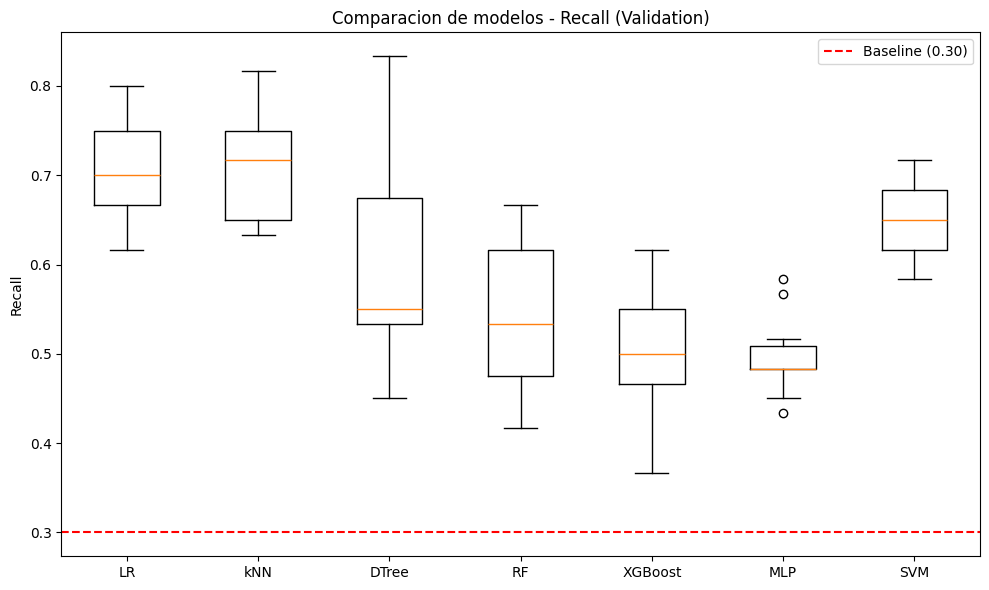

In [81]:
# Diagrama de caja del desempeño de los modelos con respecto a
# la métrica de exhaustividad (recall)

# ++++++++++++++++ Inicia sección para incluir código ++++++++++++++

fig, ax = plt.subplots(figsize=(10, 6))
datos_recall = [resultados[i]['test_recall'] for i in range(len(nombres))]
ax.boxplot(datos_recall, labels=nombres)
ax.set_ylabel('Recall')
ax.set_title('Comparacion de modelos - Recall (Validation)')
ax.axhline(y=baseline_recall, color='r', linestyle='--', label=f'Baseline ({baseline_recall:.2f})')
ax.legend()
plt.tight_layout()
plt.show()

# ++++++++++++++++ Termina sección para incluir código ++++++++++++++

# **Ejercicio 10**


>> LR
              precision    recall  f1-score   support

     good(0)       0.83      0.74      0.79       210
      bad(1)       0.52      0.66      0.58        90

    accuracy                           0.72       300
   macro avg       0.68      0.70      0.68       300
weighted avg       0.74      0.72      0.72       300



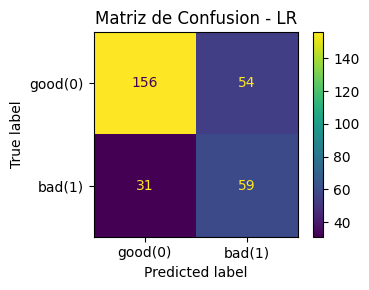


>> kNN
              precision    recall  f1-score   support

     good(0)       0.83      0.54      0.66       210
      bad(1)       0.41      0.74      0.53        90

    accuracy                           0.60       300
   macro avg       0.62      0.64      0.59       300
weighted avg       0.71      0.60      0.62       300



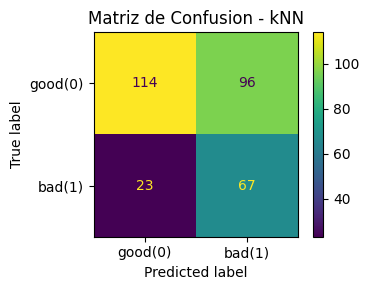


>> DTree
              precision    recall  f1-score   support

     good(0)       0.83      0.62      0.71       210
      bad(1)       0.44      0.70      0.54        90

    accuracy                           0.65       300
   macro avg       0.64      0.66      0.63       300
weighted avg       0.71      0.65      0.66       300



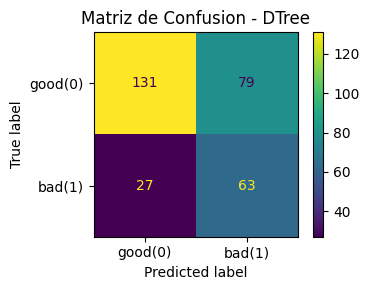


>> RF
              precision    recall  f1-score   support

     good(0)       0.80      0.80      0.80       210
      bad(1)       0.53      0.53      0.53        90

    accuracy                           0.72       300
   macro avg       0.66      0.66      0.66       300
weighted avg       0.72      0.72      0.72       300



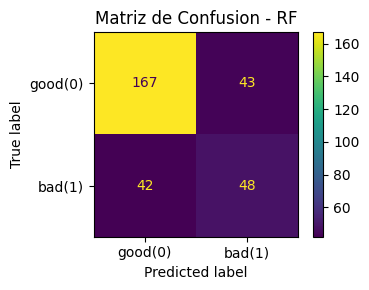


>> XGBoost
              precision    recall  f1-score   support

     good(0)       0.82      0.83      0.83       210
      bad(1)       0.59      0.57      0.58        90

    accuracy                           0.75       300
   macro avg       0.71      0.70      0.70       300
weighted avg       0.75      0.75      0.75       300



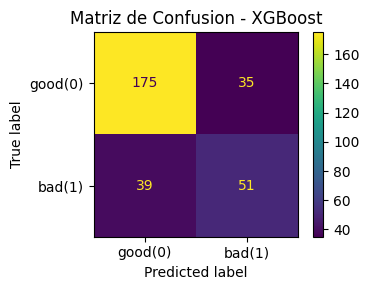


>> MLP
              precision    recall  f1-score   support

     good(0)       0.77      0.79      0.78       210
      bad(1)       0.47      0.44      0.46        90

    accuracy                           0.68       300
   macro avg       0.62      0.62      0.62       300
weighted avg       0.68      0.68      0.68       300



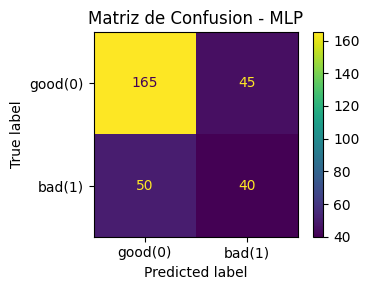


>> SVM
              precision    recall  f1-score   support

     good(0)       0.81      0.71      0.76       210
      bad(1)       0.48      0.62      0.54        90

    accuracy                           0.68       300
   macro avg       0.65      0.67      0.65       300
weighted avg       0.71      0.68      0.69       300



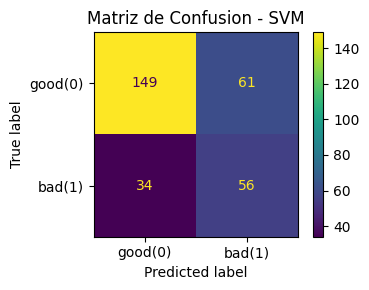

In [82]:
# 10a) Reporte de métricas

# ++++++++++++++++ Inicia sección para incluir código ++++++++++++++

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Reentrenar el mejor modelo con todo Xtt/ytt y evaluar en Xtest
for i in range(len(nombres)):
    pipeline = ImbPipeline(steps=[('ct', columnasTransformer),
                                  ('uos', SMOTE(random_state=1)),
                                  ('m', modelos[i])])
    pipeline.fit(Xtrain, ytrain)
    ypred = pipeline.predict(Xtest)

    print(f'\n{"="*50}')
    print(f'>> {nombres[i]}')
    print(f'{"="*50}')
    print(classification_report(ytest, ypred, target_names=['good(0)', 'bad(1)']))

    fig, ax = plt.subplots(figsize=(4, 3))
    ConfusionMatrixDisplay.from_predictions(ytest, ypred, display_labels=['good(0)', 'bad(1)'], ax=ax)
    ax.set_title(f'Matriz de Confusion - {nombres[i]}')
    plt.tight_layout()
    plt.show()

# ++++++++++++++++ Termina sección para incluir código ++++++++++++++

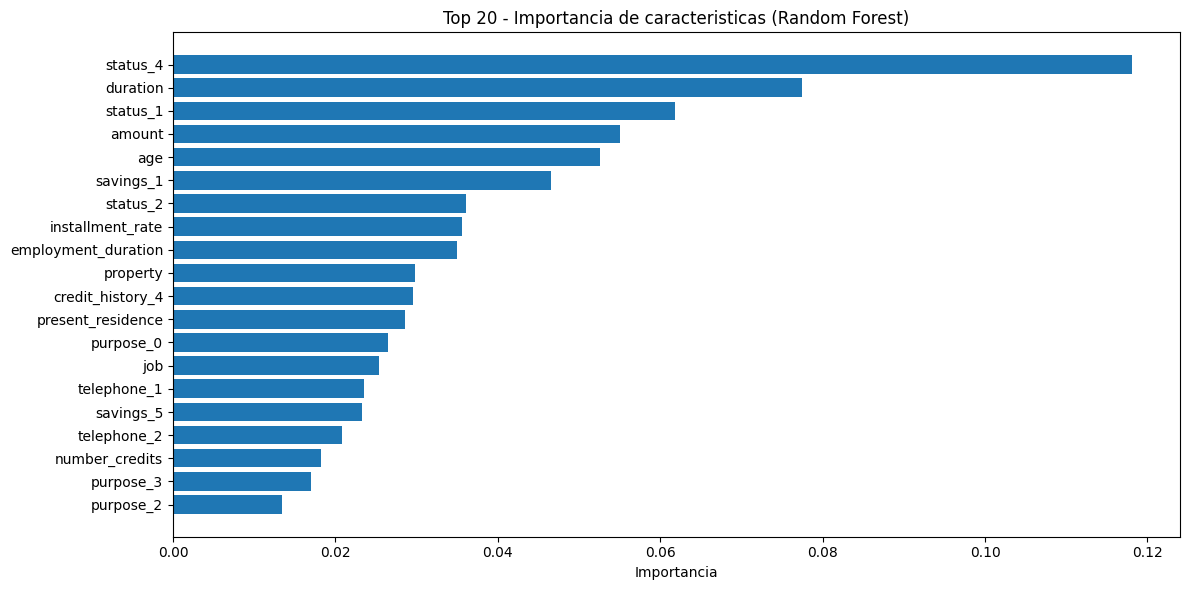

In [83]:
# 10b) Análisis de importancia de características/factores

# ++++++++++++++++ Inicia sección para incluir código ++++++++++++++

# Usamos Random Forest para obtener feature importances
rf_pipeline = ImbPipeline(steps=[('ct', columnasTransformer),
                                  ('uos', SMOTE(random_state=1)),
                                  ('m', RandomForestClassifier(n_estimators=200, max_depth=10, random_state=1))])
rf_pipeline.fit(Xtrain, ytrain)

# Obtener nombres de las features despues del ColumnTransformer
ohe_nombres = rf_pipeline.named_steps['ct'].named_transformers_['nom'].named_steps['ohe'].get_feature_names_out(list_paper_cat)
feature_names = list(list_paper_num) + list(ohe_nombres) + list(list_paper_ord)

importances = rf_pipeline.named_steps['m'].feature_importances_

# Ordenar por importancia
idx = np.argsort(importances)[::-1][:20]  # top 20

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(range(len(idx)), importances[idx][::-1])
ax.set_yticks(range(len(idx)))
ax.set_yticklabels([feature_names[i] for i in idx][::-1])
ax.set_xlabel('Importancia')
ax.set_title('Top 20 - Importancia de caracteristicas (Random Forest)')
plt.tight_layout()
plt.show()

# ++++++++++++++++ Termina sección para incluir código ++++++++++++++

* **10c) Incluye tus comentarios de los resultados obtenidos en los inciso previos de este ejercicio.**


++++++++++++++++ Inicia sección para incluir tu texto ++++++++++++++



None

++++++++++++++++ Termina sección para incluir tu texto ++++++++++++++

# **Ejercicio 11**

### **Incluyan sus conclusiones finales de la actividad.**   

++++++++++++++++ Inicia sección para incluir tu texto ++++++++++++++



None

++++++++++++++++ Termina sección para incluir tu texto ++++++++++++++

# **+++Fin de la Actividad con los datos de South_German_Credit+++**